# Does cropping explain the detectors' scores?

**The question in plain words:** every image in the panel is scored on a 200x200 pixel crop,
never the full picture. For a small photo, 200x200 might be almost the *whole* image. For a
big scan, it's a tiny slice. So "how much of the picture survives the crop" is a number that
differs a lot between real photos and AI-generated ones in this sample — real photos here tend
to be much higher-resolution, so they lose more to the crop. If a detector could quietly key off
*that* instead of actual image content, its scores would be worthless as evidence.

**What we did, in four steps:**
1. Check whether "how much got cropped away" could **by itself**, with zero pixels involved,
   guess real vs. fake — i.e. is the shortcut *available* at all.
2. Check whether the detectors actually **lean on it** — do their scores move in the direction
   the shortcut predicts, or the opposite?
3. **Remove the shortcut** (only compare images cropped by a similar amount) and see whether the
   detectors still tell real from fake — the acid test.
4. Look at *why* real photos separate the way they do, which points at a bigger, more important
   finding about scanned/archival images.

No detector is re-run here — this reads the scores `run_all.sh` already produced
(`scores/master_scores.csv`) and the crop geometry `build_manifest.py` recorded
(`manifest.csv`).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()

DETECTORS = ["cnndetection", "univfd",
             "dmimagedetection_progan", "dmimagedetection_latent",
             "aeroblade"]

REAL, FAKE = "#3b6ea5", "#c4462c"
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 9, "axes.titlelocation": "left", "axes.titleweight": "bold",
})

def auroc(score, label):
    '''Rank-based AUROC; no sklearn in this env. score first, label second -- same
    convention as merge_scores.ipynb.'''
    r = pd.Series(score).rank()
    npos, nneg = (label == 1).sum(), (label == 0).sum()
    if npos == 0 or nneg == 0:
        return np.nan
    return (r[label == 1].sum() - npos * (npos + 1) / 2) / (npos * nneg)

def spearman(a, b):
    '''Rank correlation; no scipy in this env.'''
    a, b = pd.Series(a).rank(), pd.Series(b).rank()
    a, b = a - a.mean(), b - b.mean()
    return float((a * b).sum() / np.sqrt((a * a).sum() * (b * b).sum()))

M = pd.read_csv(ROOT / "scores" / "master_scores.csv").merge(
    pd.read_csv(ROOT / "manifest.csv")[["image_id", "source_width", "source_height"]],
    on="image_id", validate="one_to_one")

# frac = the share of the ORIGINAL picture that survives the fixed 200x200 crop.
# frac = 1.0 means the source was already <=200 on its short side, so nothing was cut.
# frac near 0 means the crop is a tiny window onto a big picture (e.g. a RAISE scan).
M["frac"]   = (200 * 200) / (M.source_width * M.source_height)
M["logfrac"] = np.log10(M.frac)
M["source"] = M.image_id.str.split("/").str[0]

M[["image_id", "label", "source", "source_width", "source_height", "frac"]].head()

,image_id,label,source,source_width,source_height,frac
0,COCO2017_train/241483,0,COCO2017_train,640,426,0.146714
1,COCO2017_train/21166,0,COCO2017_train,500,333,0.240240
2,COCO2017_train/429820,0,COCO2017_train,640,427,0.146370
3,COCO2017_train/524662,0,COCO2017_train,640,480,0.130208
4,COCO2017_train/434940,0,COCO2017_train,640,480,0.130208


## Step 1 — is the shortcut even available?

If we throw away every pixel and score each image by `frac` alone (nothing but "how much of
the original photo survived the crop"), how well would that already separate real from fake?

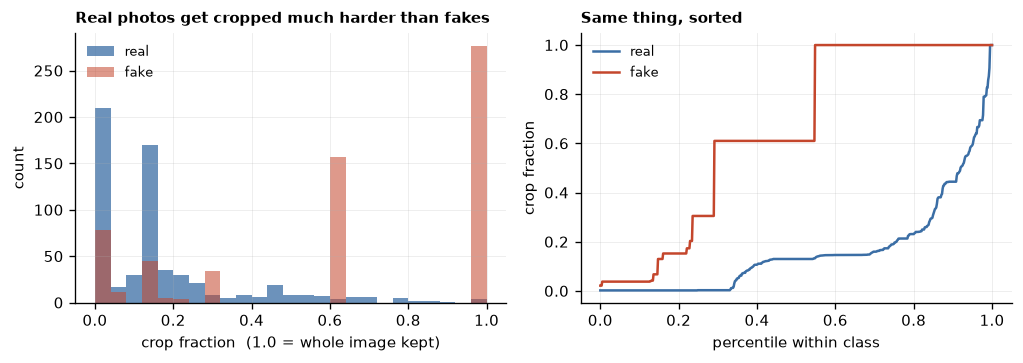

AUROC using crop fraction ALONE, no pixels at all: 0.852
fakes scored at frac=1.0 (no crop happened):   45.3%
reals scored at frac=1.0 (no crop happened):    0.7%


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.1))

bins = np.linspace(0, 1, 26)
axes[0].hist(M.loc[M.label == 0, "frac"], bins=bins, color=REAL, alpha=0.75, label="real")
axes[0].hist(M.loc[M.label == 1, "frac"], bins=bins, color=FAKE, alpha=0.55, label="fake")
axes[0].set_xlabel("crop fraction  (1.0 = whole image kept)")
axes[0].set_ylabel("count")
axes[0].set_title("Real photos get cropped much harder than fakes")
axes[0].legend(frameon=False, fontsize=8)

order = M.sort_values("frac")
axes[1].plot(np.linspace(0, 1, (order.label == 0).sum()),
             np.sort(order.loc[order.label == 0, "frac"]), color=REAL, label="real")
axes[1].plot(np.linspace(0, 1, (order.label == 1).sum()),
             np.sort(order.loc[order.label == 1, "frac"]), color=FAKE, label="fake")
axes[1].set_xlabel("percentile within class")
axes[1].set_ylabel("crop fraction")
axes[1].set_title("Same thing, sorted")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

geom_auroc = auroc(M.frac, M.label)
uncropped_fake = (M.loc[M.label == 1, "frac"] >= 0.999).mean()
uncropped_real = (M.loc[M.label == 0, "frac"] >= 0.999).mean()
print(f"AUROC using crop fraction ALONE, no pixels at all: {geom_auroc:.3f}")
print(f"fakes scored at frac=1.0 (no crop happened):  {uncropped_fake:6.1%}")
print(f"reals scored at frac=1.0 (no crop happened):  {uncropped_real:6.1%}")

**Reading this:** 0.85 AUROC from a single number that has nothing to do with image
content is high — for comparison, that's better than three of the five real detectors manage
on the actual pixels (see Step 3). Almost half the fakes (277/612) come from small source
images that survive the crop whole, while all but 4 of the 612 real photos get cut down. So the
shortcut genuinely *exists* in this sample: **if** a detector were keying off "how much of the
frame is this", it could pass as a decent fake-detector without looking at content at all. That
is the failure mode to rule out.

## Step 2 — do the detectors actually use it?

Hold the label fixed and ask, **within real photos only**: as a photo gets cropped harder
(smaller `frac`), does the detector's score drift toward "more fake" or "more real"? If a
detector were exploiting the crop shortcut, harder-cropped reals should look *more fake* to it
(matching the fake class, which is mostly uncropped... wait — the other way: fakes are mostly
*uncropped*, so a detector using the shortcut would call an uncropped image "more fake". A
heavily-cropped real should then get pulled *away* from fake, i.e. **more real**, if the
detector is reading the shortcut correctly. So a *positive* correlation (small frac -> low,
i.e. more-real score) is what the shortcut predicts. We check the sign.

correlation of (log crop fraction) with score, among REAL photos only:
positive = shortcut-consistent (harder crop -> scored more real)
negative = shortcut-backwards (harder crop -> scored MORE fake)

  cnndetection               rho = -0.361   (backwards)
  univfd                     rho = -0.539   (backwards)
  dmimagedetection_progan    rho = -0.566   (backwards)
  dmimagedetection_latent    rho = -0.395   (backwards)
  aeroblade                  rho = +0.130   (shortcut-consistent)


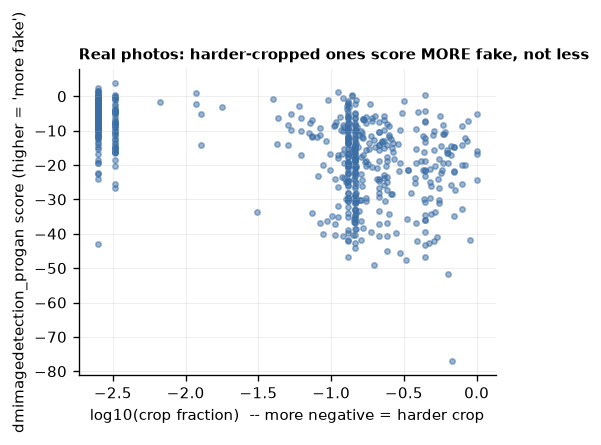

In [3]:
reals = M[M.label == 0]
corr = {d: spearman(reals.logfrac, reals[d]) for d in DETECTORS}

print("correlation of (log crop fraction) with score, among REAL photos only:")
print("positive = shortcut-consistent (harder crop -> scored more real)")
print("negative = shortcut-backwards (harder crop -> scored MORE fake)\n")
for d, r in corr.items():
    flag = "shortcut-consistent" if r > 0.1 else ("backwards" if r < -0.1 else "~flat")
    print(f"  {d:26s} rho = {r:+.3f}   ({flag})")

fig, ax = plt.subplots(figsize=(4.3, 3.4))
d = "dmimagedetection_progan"
ax.scatter(reals.logfrac, reals[d], s=10, color=REAL, alpha=0.5)
ax.set_xlabel("log10(crop fraction)  -- more negative = harder crop")
ax.set_ylabel(f"{d} score (higher = 'more fake')")
ax.set_title("Real photos: harder-cropped ones score MORE fake, not less")
fig.tight_layout()
plt.show()

**Reading this:** four of the five detectors run **backwards** from what the shortcut
predicts — the harder a real photo gets cropped, the *more fake* it scores, not less. That is
the opposite of what "cheating off the crop" would look like. So the panel is not gaining
accuracy from this shortcut; if anything the shortcut is quietly costing it accuracy on the
hardest-cropped real photos (mostly RAISE — see Step 4).

## Step 3 — the acid test: remove the shortcut and see what's left

Restrict to the band of `frac` where real and fake photos overlap a lot (so "how much was
cropped" stops being a useful guess on its own), and recompute AUROC there. If the detectors
were relying on the shortcut, taking it away should tank their AUROC. If they're reading actual
content, it should hold up — or even improve, since Step 2 showed the shortcut was working
*against* real photos.

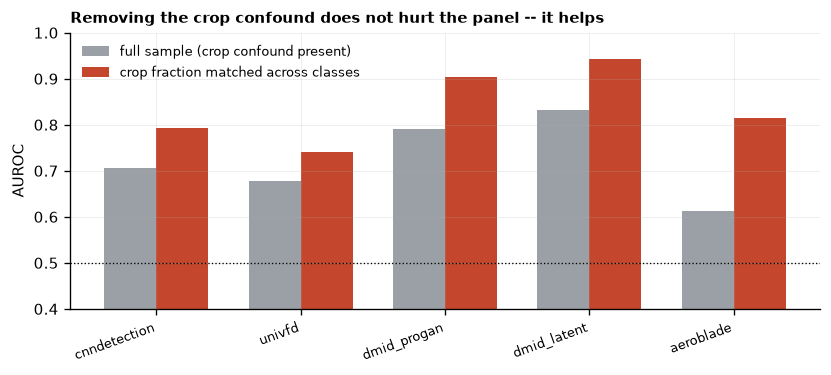

,AUROC (full sample),"AUROC (frac in [0.1,0.35), n=286 real/88 fake)"
detector,,
cnndetection,0.706,0.794
univfd,0.677,0.742
dmimagedetection_progan,0.792,0.905
dmimagedetection_latent,0.832,0.943
aeroblade,0.613,0.814


In [4]:
lo, hi = 0.10, 0.35
band = M[(M.frac >= lo) & (M.frac < hi)]
n0, n1 = (band.label == 0).sum(), (band.label == 1).sum()

rows = []
for d in DETECTORS:
    rows.append({"detector": d,
                 "AUROC (full sample)": auroc(M[d], M.label),
                 f"AUROC (frac in [{lo},{hi}), n={n0} real/{n1} fake)": auroc(band[d], band.label)})
tab = pd.DataFrame(rows).set_index("detector")

x = np.arange(len(DETECTORS))
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(x - 0.18, tab.iloc[:, 0], width=0.36, color="#9aa0a6", label="full sample (crop confound present)")
ax.bar(x + 0.18, tab.iloc[:, 1], width=0.36, color=FAKE, label="crop fraction matched across classes")
ax.axhline(0.5, color="black", lw=0.8, ls=":")
ax.set_xticks(x); ax.set_xticklabels([d.replace("dmimagedetection_", "dmid_") for d in DETECTORS],
                                       rotation=20, ha="right", fontsize=8)
ax.set_ylabel("AUROC")
ax.set_ylim(0.4, 1.0)
ax.set_title("Removing the crop confound does not hurt the panel -- it helps")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

tab.round(3)

**Reading this:** every detector except AEROBLADE gets *better*, not worse, once crop
fraction can no longer help — DMimageDetection's diffusion checkpoint goes from 0.83 to 0.94.
That is the clearest evidence the panel's real/fake separation is not a crop-geometry artifact:
taking the shortcut away improves scores, so the reported AUROCs are, if anything, an
*underestimate* of how well the detectors read actual content.

## Step 4 — so where does the confound in Step 1 actually come from?

Not from cropping *causing* a detector mistake — from **RAISE**, the one authentic source in
this sample that behaves like a scanned archival image: camera-raw, very high resolution
(2000x3008 to 4928x3264), no history of web JPEG re-encoding. Its photos get the hardest crop of
any source, and — separately, per Step 2 — they are also the real photos the panel is worst at.
This is a live preview of the thesis's central open question (**"Fake or JPEG?" / archival
domain gap** — do unusual-but-authentic compression/processing histories get mistaken for
generation artifacts?), showing up in the current sample before we've digitized a single scan.

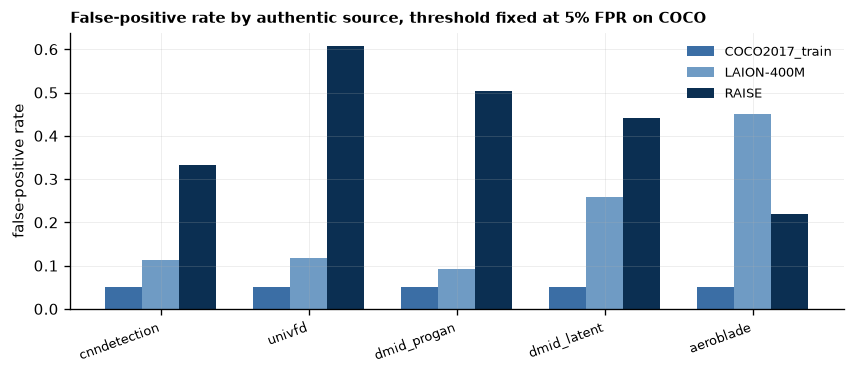

,threshold (5% FPR on COCO),COCO2017_train,LAION-400M,RAISE,fakes flagged (TPR)
detector,,,,,
cnndetection,-9.169,0.051,0.113,0.333,0.423
univfd,-2.437,0.051,0.118,0.608,0.466
dmimagedetection_progan,-5.290,0.051,0.093,0.505,0.577
dmimagedetection_latent,-6.997,0.051,0.260,0.441,0.735
aeroblade,-0.027,0.051,0.451,0.221,0.353


In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
sources = ["COCO2017_train", "LAION-400M", "RAISE"]
colors = ["#3b6ea5", "#6f9bc4", "#0b2f52"]  # light -> dark, same hue family as REAL

fpr_rows = []
for d in DETECTORS:
    thr = np.quantile(M.loc[M.source == "COCO2017_train", d], 0.95)  # threshold = 5% FPR on COCO
    row = {"detector": d, "threshold (5% FPR on COCO)": thr}
    for s in sources:
        row[s] = (M.loc[M.source == s, d] > thr).mean()
    row["fakes flagged (TPR)"] = (M.loc[M.label == 1, d] > thr).mean()
    fpr_rows.append(row)
fpr_tab = pd.DataFrame(fpr_rows).set_index("detector")

x = np.arange(len(DETECTORS))
w = 0.25
for i, s in enumerate(sources):
    ax.bar(x + (i - 1) * w, fpr_tab[s], width=w, color=colors[i], label=s)
ax.set_xticks(x); ax.set_xticklabels([d.replace("dmimagedetection_", "dmid_") for d in DETECTORS],
                                       rotation=20, ha="right", fontsize=8)
ax.set_ylabel("false-positive rate")
ax.set_title("False-positive rate by authentic source, threshold fixed at 5% FPR on COCO")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

fpr_tab.round(3)

**Reading this:** at a threshold tuned to a 5% false-positive rate on ordinary web photos
(COCO), the same threshold false-flags **11–61%** of RAISE photos, depending on the detector —
UnivFD is worst (61%) and is actually *below chance* on RAISE alone. RAISE is real, camera-raw,
never AI-generated; the detectors are reading "unusual capture/processing pipeline" as a
generation artifact. That's the false-positive risk the thesis's archival-domain-gap question is
built to measure — this sample is showing an early, undersized version of it.

## Summary, in plain words

- **The shortcut exists**: crop amount alone predicts real vs. fake at 0.85 AUROC in this
  sample, because real photos here are mostly high-resolution and get cropped hard, while about
  half the fakes are small enough to survive the crop whole.
- **The detectors are not using it** — three of five even run backwards from what the shortcut
  predicts. Taking the shortcut away (Step 3) makes every non-AEROBLADE detector's score *look
  better*, not worse, which rules out the panel gaining accuracy from crop geometry.
- **What actually explains the confound** is RAISE (the sample's high-res, camera-raw source)
  being both the hardest-cropped and the hardest-to-classify authentic source — a preview of the
  "Fake or JPEG?" archival domain gap, not a crop-policy bug.

### Caveats
- This is correlational, on one sample of 612+612 images. It shows the panel *isn't currently*
  exploiting crop geometry — it doesn't prove no detector ever could.
- RAISE-ness and crop fraction are confounded with each other here (RAISE is the only source at
  the extreme end of `frac`), so Step 4's causal story can't be fully separated from Step 1-3's
  correlational one with this data alone.
- AUROC is used here only as a diagnostic (per `merge_scores.ipynb`, it's the wrong headline
  metric for this project) — this notebook doesn't touch Cllr/DET/Tippett.

### Suggested next step (~20 min, optional)
Take a handful of RAISE images, generate several crops at different `frac` values from the
*same* source image, and rescore. That turns this correlational read into a controlled,
causal one: same content, only crop fraction changes.